# Radix 2 and 2^2 FFT

In [1]:
import numpy as np
import fxpmath as fxp
from scipy.fft import fft, ifft

In [14]:
class radix2_PreAdder:
    def __init__(self):
        self.input_a = 0.0
        self.input_b = 0.0
        self.output_add = 0.0
        self.output_sub = 0.0


    def calculate(self):
        self.output_add = self.input_a + self.input_b
        self.output_sub = self.input_a - self.input_b
        

class radix2_Rotator:
    cnt = 0
    def __init__(self, stage_index, num_of_stages):
        self.input = 0.0
        self.output = 0.0
        self.stage_index = stage_index
        self.twiddleROM = (np.ones(2**(num_of_stages-stage_index))).astype(complex)
        self.half_len = 2**(num_of_stages-stage_index-1)
        N = 2**num_of_stages
        for i in range(self.half_len):
            k = i * 2**(stage_index)
            self.twiddleROM[i+self.half_len] = np.exp(-1j*2*np.pi*k/N)
        
        print(f"STAGE {stage_index}, twiddle = {self.twiddleROM}")

        # print(self.twiddleROM)

    def rotate(self, fifo_full_flag):
        if (fifo_full_flag): # dozvola da brojac vrti i cita redom twiddle faktore iz memorije
            print(f"STAGE {self.stage_index}, FIFO FULL")
            self.output = self.input * self.twiddleROM[self.cnt]
            print(f'STAGE {self.stage_index}, curr twiddle = {self.twiddleROM[self.cnt]}')
            if (self.cnt == self.half_len*2-1):
                self.cnt = 0
            else:
                self.cnt += 1
        

class Fifo:
    full = 0
    cnt = 0

    def __init__(self, depth):
        self.depth = depth
        self.buffer = (np.zeros(depth)).astype(complex)
        # print(self.depth)

    def is_full(self):
        return self.full
    
    def get_output(self):
        return self.buffer[-1]
    
    def shift(self, input_sample):
        self.cnt += 1
        self.buffer = np.roll(self.buffer, 1)
        self.buffer[0] = input_sample
        if (self.cnt > self.depth):
            self.full = 1
        else:
            self.full = 0



In [15]:
class radix2_SDF_stage:
    input_sample = 0.0
    output_sample = 0.0
    op_cnt = 0 # operation counter (counting how many add/subb operations are done)
    def __init__(self, stage_index, num_of_stages):
        self.stage_index = stage_index
        self.num_of_stages = num_of_stages
        self.num_of_samples = 2**(num_of_stages-stage_index)
        self.fifo = Fifo(2**(num_of_stages-stage_index-1))
        self.pre_adder = radix2_PreAdder()
        self.rotator = radix2_Rotator(stage_index=stage_index, num_of_stages=num_of_stages)

    def isFifoFull(self):
        return self.fifo.is_full()
    
    def calculate(self):
        print(f'STAGE {self.stage_index}, op_cnt = ', self.op_cnt)
        self.pre_adder.input_a = self.fifo.get_output()
        self.pre_adder.input_b = self.input_sample
        self.pre_adder.calculate()

        print(f'STAGE {self.stage_index}, add_out = {self.pre_adder.output_add}')
        print(f'STAGE {self.stage_index}, sub_out = {self.pre_adder.output_sub}')
        
        if (self.op_cnt//(self.num_of_samples/2)): ## other half of the input stream is comming
            self.output_sample = self.pre_adder.output_add
            self.fifo.shift(self.pre_adder.output_sub) 
        else:
            self.output_sample = self.fifo.get_output()
            self.fifo.shift(self.input_sample)

        self.rotator.input = self.output_sample
        self.rotator.rotate(self.isFifoFull())
        self.output_sample = self.rotator.output

        # print(f'stage_{self.stage_index} : {self.output_sample}')

        if (self.op_cnt == self.num_of_samples-1):
            self.op_cnt = 0
        else:
            self.op_cnt += 1

        print(f'STAGE {self.stage_index}, output = {self.output_sample}')


In [16]:
stage0 = radix2_SDF_stage(stage_index=0, num_of_stages=3)
stage1 = radix2_SDF_stage(stage_index=1, num_of_stages=3)
stage2 = radix2_SDF_stage(stage_index=2, num_of_stages=3)


# input_vector = [1.0, 2.0, 3.0, 4.0, 0.0, 0.0, 0.0]
# input_vector = [4.0, 3.0, 2.0, 1.0, 0.0, 0.0, 0.0, 0.0]

# input_vector = [1.0, 1.0, 0.0]
input_vector = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
fft_manual = []
for i in range(len(input_vector)):
    stage0.input_sample = input_vector[i]
    stage0.calculate()
    stage1.input_sample = stage0.output_sample
    stage1.calculate()
    stage2.input_sample = stage1.output_sample
    stage2.calculate()
    print(stage2.output_sample)
    if i > 6:
        fft_manual.append(stage2.output_sample)


STAGE 0, twiddle = [ 1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          7.07106781e-01-0.70710678j
  6.12323400e-17-1.j         -7.07106781e-01-0.70710678j]
STAGE 1, twiddle = [1.000000e+00+0.j 1.000000e+00+0.j 1.000000e+00+0.j 6.123234e-17-1.j]
STAGE 2, twiddle = [1.+0.j 1.+0.j]
STAGE 0, op_cnt =  0
STAGE 0, add_out = (1+0j)
STAGE 0, sub_out = (-1+0j)
STAGE 0, output = 0.0
STAGE 1, op_cnt =  0
STAGE 1, add_out = 0j
STAGE 1, sub_out = 0j
STAGE 1, output = 0.0
STAGE 2, op_cnt =  0
STAGE 2, add_out = 0j
STAGE 2, sub_out = 0j
STAGE 2, output = 0.0
0.0
STAGE 0, op_cnt =  1
STAGE 0, add_out = (2+0j)
STAGE 0, sub_out = (-2+0j)
STAGE 0, output = 0.0
STAGE 1, op_cnt =  1
STAGE 1, add_out = 0j
STAGE 1, sub_out = 0j
STAGE 1, output = 0.0
STAGE 2, op_cnt =  1
STAGE 2, add_out = 0j
STAGE 2, sub_out = 0j
STAGE 2, FIFO FULL
STAGE 2, curr twiddle = (1+0j)
STAGE 2, output = 0j
0j
STAGE 0, op_cnt =  2
STAGE 0, add_out = (3+0j)
S

In [5]:
def bracewell_buneman(xarray, length, log2length):
    ''' 
    bracewell-buneman bit reversal function
    inputs: xarray is array; length is array length; log2length=log2(length).
    output: bit reversed array xarray. 
    '''
    muplus = int((log2length+1)/2)
    mvar = 1
    reverse = np.zeros(length, dtype = int)
    upper_range = muplus+1
    for _ in np.arange(1, upper_range):
        for kvar in np.arange(0, mvar):
            tvar = 2*reverse[kvar]
            reverse[kvar] = tvar
            reverse[kvar+mvar] = tvar+1
        mvar = mvar+mvar
    if (log2length & 0x01):
            mvar = mvar/2

    mvar = int(mvar)
    for qvar in np.arange(1, mvar):
        
        nprime = qvar-mvar
        rprimeprime = reverse[qvar]*mvar
        for pvar in np.arange(0, reverse[qvar]):
            nprime = nprime+mvar
            rprime = rprimeprime+reverse[pvar]
            temp = xarray[nprime]
            xarray[nprime] = xarray[rprime]
            xarray[rprime] = temp
    return xarray

In [9]:
# print(fft_manual)
fft_manual = np.array(bracewell_buneman(fft_manual, len(fft_manual), int(np.log2(len(fft_manual)))))
print(fft_manual)

[36.+0.j         -4.+9.65685425j -4.+4.j         -4.+1.65685425j
 -4.+0.j         -4.-1.65685425j -4.-4.j         -4.-9.65685425j]


In [12]:
# input_vector = [1.0, 1.0]
input_vector = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
# input_vector = [1.0, 2.0, 3.0, 4.0]
fft_numpy = np.fft.fft(input_vector)
print(fft_numpy)

[36.+0.j         -4.+9.65685425j -4.+4.j         -4.+1.65685425j
 -4.+0.j         -4.-1.65685425j -4.-4.j         -4.-9.65685425j]


In [13]:
print(np.allclose(fft_manual,fft_numpy))

True


## Radix-3 butterfly

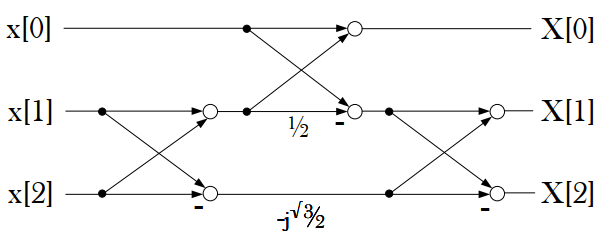